<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/huang_baseline_exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
# CELL 1 — Install, import, paths

!pip -q install mne pymatreader scipy scikit-learn pandas numpy tqdm

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import mne

from tqdm import tqdm
from pymatreader import read_mat
from scipy.linalg import eigh

from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

In [ ]:
EXP8_DIR = "/content/drive/MyDrive/my dataset_raw_main_exp8"
REREF_DIR = os.path.join(EXP8_DIR, "derivatives", "rerefer")

OUT_DIR = "/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED"
os.makedirs(OUT_DIR, exist_ok=True)

set_files = sorted(glob.glob(os.path.join(REREF_DIR, "*.set")))

print("Total Exp8 .set files:", len(set_files))
print("REREF_DIR:", REREF_DIR)
print("OUT_DIR:", OUT_DIR)

Total Exp8 .set files: 223
REREF_DIR: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer
OUT_DIR: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED


In [ ]:
# CELL 2 — Huang-corrected parameters

# Huang used 64-channel Brain Products extended 10–20.
# We keep common LEP scalp channels and avoid EOG/peripheral missing FT9/FT10.
target_channels = [
    "Fp1", "Fp2",
    "F7", "F3", "Fz", "F4", "F8",
    "FC5", "FC1", "FC2", "FC6",
    "C3", "Cz", "C4",
    "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8",
    "O1", "Oz", "O2"
]

# Huang: 1–30 Hz zero-phase filtering
l_freq = 1.0
h_freq = 30.0

# Huang: epochs from -500 ms to +1000 ms
analysis_window = (-0.5, 1.0)

# Huang: baseline correction using pre-stimulus interval
baseline_window = (-0.5, 0.0)

# Huang CSP: pre-stimulus -500–0 ms, post-stimulus 0–500 ms
pre_window = (-0.5, 0.0)
post_window = (0.0, 0.5)

# N2/P2 approximate windows for template separation
n2_window = (0.150, 0.300)
p2_window = (0.300, 0.450)

# Huang selected 3 CSP components
n_csp_components = 3

print("Label rule:")
print("NRS 0–4 = low pain = 0")
print("NRS 5–10 = high pain = 1")

Label rule:
NRS 0–4 = low pain = 0
NRS 5–10 = high pain = 1


In [ ]:
# CELL 3 — Helper functions

def safe_scalar(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        return safe_scalar(x.flatten()[0])
    if isinstance(x, list):
        if len(x) == 0:
            return np.nan
        return safe_scalar(x[0])
    return x

def listify(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return list(x.flatten())
    return [x]

def extract_exp8_rating_laser_from_mat(mat, n_trials):
    pain = [np.nan] * n_trials
    laser = [np.nan] * n_trials

    epoch = mat.get("epoch", None)

    if isinstance(epoch, dict):
        if "eventrating" in epoch:
            vals = listify(epoch["eventrating"])
            for i in range(min(len(vals), n_trials)):
                pain[i] = safe_scalar(vals[i])

        if "eventlaser_power" in epoch:
            vals = listify(epoch["eventlaser_power"])
            for i in range(min(len(vals), n_trials)):
                laser[i] = safe_scalar(vals[i])

    elif isinstance(epoch, list):
        for i in range(min(len(epoch), n_trials)):
            ep = epoch[i]
            if isinstance(ep, dict):
                if "eventrating" in ep:
                    pain[i] = safe_scalar(ep["eventrating"])
                if "eventlaser_power" in ep:
                    laser[i] = safe_scalar(ep["eventlaser_power"])

    return np.array(pain, dtype=float), np.array(laser, dtype=float)

def classification_metrics(y_true, y_pred, y_prob=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_true, y_prob)
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan

    return out

In [ ]:
# CELL 4 — Find common available Huang channels

all_channel_sets = []

for fp in tqdm(set_files, desc="Reading channel names"):
    epochs = mne.io.read_epochs_eeglab(fp, verbose=False)
    all_channel_sets.append(set(epochs.ch_names))

common_channels = set.intersection(*all_channel_sets)
huang_common_channels = [ch for ch in target_channels if ch in common_channels]

print("Target channels:", len(target_channels))
print("Common channels used:", len(huang_common_channels))
print(huang_common_channels)

if "Cz" not in huang_common_channels:
    raise ValueError("Cz is not present in all subjects. Stop and inspect.")

Reading channel names: 100%|██████████| 223/223 [07:36<00:00,  2.05s/it]

Target channels: 26
Common channels used: 26
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'C3', 'Cz', 'C4', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2']


In [ ]:
# CELL 5 — Load Exp8 signal with corrected Huang preprocessing

X_list = []
rating_list = []
laser_list = []
subject_list = []
trial_list = []

final_times = None
final_channels = None

for fp in tqdm(set_files, desc="Loading Exp8 EEG"):
    subject_id = os.path.basename(fp).split("_")[0]

    epochs = mne.io.read_epochs_eeglab(fp, verbose=False)
    epochs = epochs.copy().pick(huang_common_channels)

    # Crop to Huang epoch first: -0.5 to +1.0 s
    epochs.crop(tmin=analysis_window[0], tmax=analysis_window[1])

    # Huang: 1–30 Hz zero-phase filtering
    epochs.filter(
        l_freq=l_freq,
        h_freq=h_freq,
        method="fir",
        phase="zero",
        verbose=False
    )

    # Huang: baseline correction using pre-stimulus interval
    epochs.apply_baseline(baseline_window)

    data = epochs.get_data()
    times = epochs.times

    mat = read_mat(fp)
    n_trials = data.shape[0]

    ratings, lasers = extract_exp8_rating_laser_from_mat(mat, n_trials)

    X_list.append(data)
    rating_list.append(ratings)
    laser_list.append(lasers)

    subject_list.extend([subject_id] * n_trials)
    trial_list.extend(np.arange(1, n_trials + 1))

    final_times = times
    final_channels = epochs.ch_names

X_signal = np.concatenate(X_list, axis=0)
y_rating = np.concatenate(rating_list)
laser_power = np.concatenate(laser_list)
groups = np.array(subject_list)
trial_num = np.array(trial_list)

times = final_times
channels = final_channels
cz_idx = channels.index("Cz")

# NRS <5 low, NRS >=5 high
y_label = (y_rating >= 5).astype(int)

print("X_signal shape:", X_signal.shape)
print("Ratings shape:", y_rating.shape)
print("Labels shape:", y_label.shape)
print("Subjects:", len(np.unique(groups)))
print("Channels used:", len(channels))
print("Time range:", times[0], "to", times[-1])
print("Class counts:", pd.Series(y_label).value_counts().to_dict())

Loading Exp8 EEG:   0%|          | 0/223 [00:00<?, ?it/s]

Applying baseline correction (mode: mean)


Loading Exp8 EEG:   0%|          | 1/223 [00:00<03:11,  1.16it/s]

Applying baseline correction (mode: mean)


Loading Exp8 EEG:   1%|          | 2/223 [00:01<02:54,  1.26it/s]

...

Applying baseline correction (mode: mean)


Loading Exp8 EEG: 100%|█████████▉| 222/223 [03:20<00:00,  1.13it/s]

Applying baseline correction (mode: mean)


Loading Exp8 EEG: 100%|██████████| 223/223 [03:21<00:00,  1.11it/s]


X_signal shape: (6275, 26, 1501)
Ratings shape: (6275,)
Labels shape: (6275,)
Subjects: 223
Channels used: 26
Time range: -0.5 to 1.0
Class counts: {1: 3550, 0: 2725}


In [ ]:
# SAVE CELL 5 OUTPUTS

import os
import numpy as np
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED"
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(os.path.join(SAVE_DIR, "X_signal.npy"), X_signal)
np.save(os.path.join(SAVE_DIR, "y_rating.npy"), y_rating)
np.save(os.path.join(SAVE_DIR, "y_label.npy"), y_label)
np.save(os.path.join(SAVE_DIR, "laser_power.npy"), laser_power)
np.save(os.path.join(SAVE_DIR, "groups.npy"), groups)
np.save(os.path.join(SAVE_DIR, "trial_num.npy"), trial_num)
np.save(os.path.join(SAVE_DIR, "times.npy"), times)

pd.DataFrame({"channel": channels}).to_csv(
    os.path.join(SAVE_DIR, "channels.csv"), index=False
)

print("Saved Cell 5 outputs to:", SAVE_DIR)

Saved Cell 5 outputs to: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED


In [ ]:
print("times exists:", "times" in globals())
print("X_signal exists:", "X_signal" in globals())
print("groups exists:", "groups" in globals())

times exists: True
X_signal exists: True
groups exists: True


In [ ]:
# CELL 6 — Huang CSP + Eq(3) beta extraction functions

from scipy.linalg import eigh
import numpy as np
import pandas as pd

pre_mask = (times >= pre_window[0]) & (times < pre_window[1])
post_mask = (times >= post_window[0]) & (times <= post_window[1])
post_times = times[post_mask]

def mean_cov(trials):
    covs = []
    for ep in trials:
        c = ep @ ep.T
        tr = np.trace(c)
        if tr > 0:
            c = c / tr
        covs.append(c)
    return np.mean(covs, axis=0)

def fit_huang_csp(X_train):
    X_pre = X_train[:, :, pre_mask]
    X_post = X_train[:, :, post_mask]

    Cpre = mean_cov(X_pre)
    Cpost = mean_cov(X_post)

    vals, vecs = eigh(Cpost, Cpre)

    order = np.argsort(vals)[::-1]
    selected = order[:n_csp_components]

    W_full = vecs
    W_sel = vecs[:, selected]

    A_full = np.linalg.pinv(W_full.T)
    A_sel = A_full[:, selected]

    return W_sel, A_sel

def apply_csp_reconstruct(X_data, W_sel, A_sel):
    projected = np.einsum("cf,nft->nct", W_sel.T, X_data)
    reconstructed = np.einsum("fc,nct->nft", A_sel, projected)
    return reconstructed

def make_np_templates(train_cz_post):
    avg = train_cz_post.mean(axis=0)

    yN = np.zeros_like(avg)
    yP = np.zeros_like(avg)

    n_mask = (post_times >= n2_window[0]) & (post_times <= n2_window[1])
    p_mask = (post_times >= p2_window[0]) & (post_times <= p2_window[1])

    yN[n_mask] = avg[n_mask]
    yP[p_mask] = avg[p_mask]

    yN_der = np.gradient(yN)
    yP_der = np.gradient(yP)

    D = np.column_stack([
        yN,
        yN_der,
        yP,
        yP_der,
        np.ones_like(yN)
    ])

    for j in range(4):
        D[:, j] = (D[:, j] - D[:, j].mean()) / (D[:, j].std() + 1e-8)

    return D

def extract_eq3_betas(cz_post_trials, D):
    betas = []
    for sig in cz_post_trials:
        beta = np.linalg.lstsq(D, sig, rcond=None)[0]
        betas.append(beta)

    return pd.DataFrame(
        betas,
        columns=[
            "beta1_N2_amp",
            "beta2_N2_latency",
            "beta3_P2_amp",
            "beta4_P2_latency",
            "beta5_constant"
        ]
    )

print("Cell 6 loaded successfully.")
print("pre_mask samples:", pre_mask.sum())
print("post_mask samples:", post_mask.sum())

Cell 6 loaded successfully.
pre_mask samples: 500
post_mask samples: 501


In [ ]:
# Huang-faithful WITHIN-INDIVIDUAL classification
# Leave-one-trial-out within subject, no feature scaling

from sklearn.model_selection import LeaveOneOut
from sklearn.naive_bayes import GaussianNB

within_subject_rows = []
within_pred_rows = []
within_beta_rows = []

unique_subjects = sorted(np.unique(groups))

for subj in tqdm(unique_subjects, desc="Within-subject Huang faithful"):

    subj_idx = np.where(groups == subj)[0]

    X_subj = X_signal[subj_idx]
    y_subj = y_label[subj_idx]
    rating_subj = y_rating[subj_idx]
    laser_subj = laser_power[subj_idx]
    trial_subj = trial_num[subj_idx]

    # Within-individual classification needs both classes
    if len(np.unique(y_subj)) < 2:
        continue

    loo = LeaveOneOut()

    subj_pred = []
    subj_prob = []
    subj_true = []
    subj_trial = []
    subj_rating = []
    subj_laser = []

    for loo_fold, (train_local, test_local) in enumerate(loo.split(X_subj), start=1):

        X_train = X_subj[train_local]
        X_test = X_subj[test_local]

        y_train = y_subj[train_local]
        y_test = y_subj[test_local]

        if len(np.unique(y_train)) < 2:
            continue

        # 1. CSP learned from training trials only
        W_sel, A_sel = fit_huang_csp(X_train)

        # 2. Reconstruct LEP
        X_train_rec = apply_csp_reconstruct(X_train, W_sel, A_sel)
        X_test_rec = apply_csp_reconstruct(X_test, W_sel, A_sel)

        # 3. Cz post-stimulus response
        train_cz_post = X_train_rec[:, cz_idx, :][:, post_mask]
        test_cz_post = X_test_rec[:, cz_idx, :][:, post_mask]

        # 4. Eq(3) template from training trials only
        D = make_np_templates(train_cz_post)

        # 5. β1–β5 features
        train_beta = extract_eq3_betas(train_cz_post, D)
        test_beta = extract_eq3_betas(test_cz_post, D)

        # 6. No scaling
        Xtr = train_beta.values
        Xte = test_beta.values

        # 7. Naive Bayes
        clf = GaussianNB()
        clf.fit(Xtr, y_train)

        pred = clf.predict(Xte)[0]
        prob = clf.predict_proba(Xte)[0, 1]

        subj_pred.append(pred)
        subj_prob.append(prob)
        subj_true.append(y_test[0])
        subj_trial.append(trial_subj[test_local][0])
        subj_rating.append(rating_subj[test_local][0])
        subj_laser.append(laser_subj[test_local][0])

        temp_beta = test_beta.copy()
        temp_beta.insert(0, "subject_id", subj)
        temp_beta.insert(1, "trial_num", trial_subj[test_local][0])
        temp_beta.insert(2, "painrating", rating_subj[test_local][0])
        temp_beta.insert(3, "pain_label", y_test[0])
        temp_beta.insert(4, "loo_fold", loo_fold)
        within_beta_rows.append(temp_beta)

    if len(subj_true) == 0:
        continue

    subj_true = np.array(subj_true)
    subj_pred = np.array(subj_pred)
    subj_prob = np.array(subj_prob)

    m = classification_metrics(subj_true, subj_pred, subj_prob)

    within_subject_rows.append({
        "subject_id": subj,
        "n_trials": len(y_subj),
        "n_valid_loo_trials": len(subj_true),
        "low_count": int((y_subj == 0).sum()),
        "high_count": int((y_subj == 1).sum()),
        **m
    })

    temp_pred = pd.DataFrame({
        "subject_id": subj,
        "trial_num": subj_trial,
        "painrating": subj_rating,
        "pain_label": subj_true,
        "laser_power": subj_laser,
        "prediction": subj_pred,
        "prob_high": subj_prob
    })
    within_pred_rows.append(temp_pred)

within_subject_df = pd.DataFrame(within_subject_rows)
within_pred_df = pd.concat(within_pred_rows, ignore_index=True)
within_beta_df = pd.concat(within_beta_rows, ignore_index=True)

within_summary = classification_metrics(
    within_pred_df["pain_label"].values,
    within_pred_df["prediction"].values,
    within_pred_df["prob_high"].values
)

within_summary_df = pd.DataFrame([{
    "experiment": "EXP8",
    "pipeline": "Huang Eq(3) faithful reconstructed baseline",
    "feature_set": "beta1-beta5",
    "classifier": "Gaussian Naive Bayes",
    "validation": "Leave-one-trial-out within-individual",
    "normalization": "None",
    "subjects_used": within_subject_df["subject_id"].nunique(),
    "trials_used": len(within_pred_df),
    **within_summary
}])

display(within_summary_df)
display(within_subject_df.head())

Within-subject Huang faithful: 100%|██████████| 223/223 [03:42<00:00,  1.00it/s]


,experiment,pipeline,feature_set,classifier,validation,normalization,subjects_used,trials_used,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,EXP8,Huang Eq(3) faithful reconstructed baseline,beta1-beta5,Gaussian Naive Bayes,Leave-one-trial-out within-individual,None,205,5755,0.758645,0.7575,0.786015,0.769328,0.777582,0.834143


,subject_id,n_trials,n_valid_loo_trials,low_count,high_count,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,sub-001,28,28,11,17,0.750000,0.713904,0.750000,0.882353,0.810811,0.695187
1,sub-002,25,25,23,2,0.880000,0.478261,0.000000,0.000000,0.000000,0.000000
2,sub-003,25,25,18,7,0.880000,0.829365,0.833333,0.714286,0.769231,0.857143
3,sub-004,27,27,6,21,0.703704,0.571429,0.809524,0.809524,0.809524,0.523810
4,sub-005,27,27,13,14,0.444444,0.439560,0.470588,0.571429,0.516129,0.412088


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED"
os.makedirs(SAVE_DIR, exist_ok=True)

within_subject_df.to_csv(os.path.join(SAVE_DIR, "EXP8_Huang_faithful_within_individual_subject_results.csv"), index=False)
within_pred_df.to_csv(os.path.join(SAVE_DIR, "EXP8_Huang_faithful_within_individual_predictions.csv"), index=False)
within_beta_df.to_csv(os.path.join(SAVE_DIR, "EXP8_Huang_faithful_within_individual_beta_features.csv"), index=False)
within_summary_df.to_csv(os.path.join(SAVE_DIR, "EXP8_Huang_faithful_within_individual_summary.csv"), index=False)

print("Saved within-individual results successfully.")
print(SAVE_DIR)

Saved within-individual results successfully.
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED


In [ ]:
# ===========================================
# Save Huang faithful WITHIN-INDIVIDUAL results
# ===========================================

import os

SAVE_DIR = os.path.join(OUT_DIR, "saved_results")
os.makedirs(SAVE_DIR, exist_ok=True)

within_summary_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_within_individual_summary.csv"
)

within_subject_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_within_individual_subject_results.csv"
)

within_prediction_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_within_individual_predictions.csv"
)

within_beta_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_within_individual_beta_features.csv"
)

within_summary_df.to_csv(within_summary_path, index=False)
within_subject_df.to_csv(within_subject_path, index=False)
within_pred_df.to_csv(within_prediction_path, index=False)
within_beta_df.to_csv(within_beta_path, index=False)

print("="*60)
print("Huang faithful WITHIN-INDIVIDUAL results saved successfully.")
print("="*60)
print(within_summary_path)
print(within_subject_path)
print(within_prediction_path)
print(within_beta_path)

Huang faithful WITHIN-INDIVIDUAL results saved successfully.
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_within_individual_summary.csv
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_within_individual_subject_results.csv
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_within_individual_predictions.csv
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_within_individual_beta_features.csv


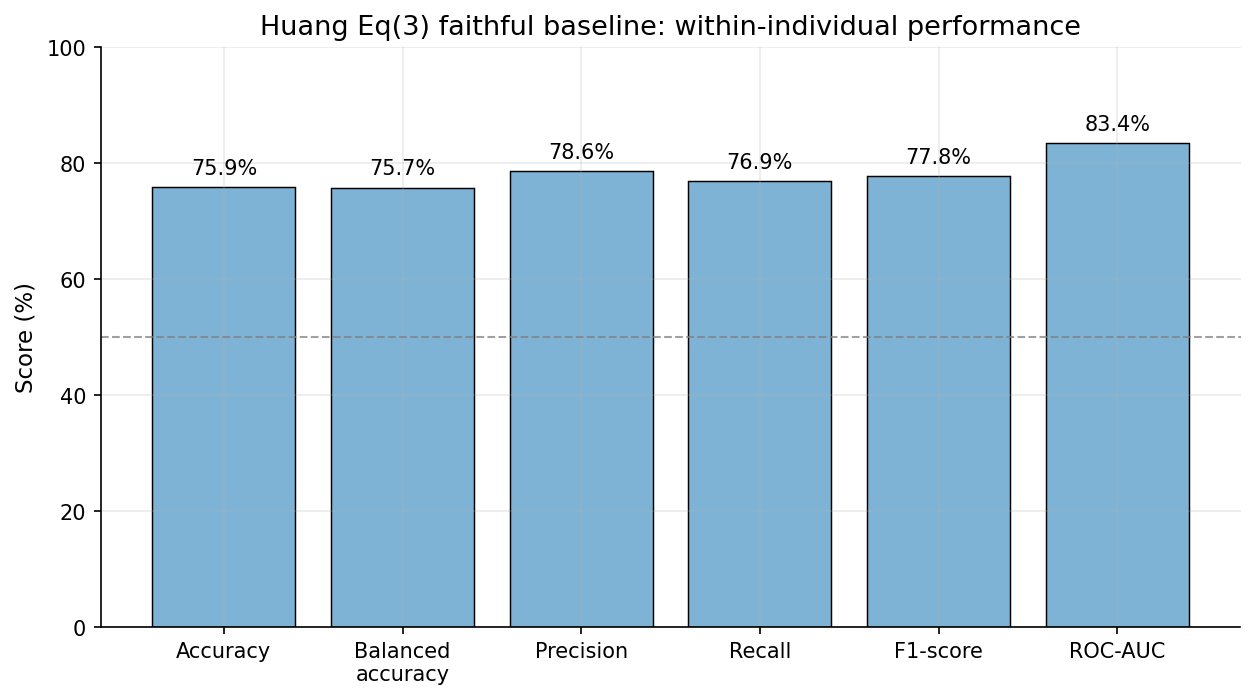

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_within_individual_metric_summary.png


In [ ]:
# VISUALIZATION CELL — Huang within-individual faithful baseline

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
})

# 1. Summary metric bar plot

metrics = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Balanced\naccuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
metric_values = [within_summary[m] * 100 for m in metrics]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.bar(
    metric_labels,
    metric_values,
    color="#7FB3D5",
    edgecolor="black",
    linewidth=0.7
)

ax.set_ylim(0, 100)
ax.set_ylabel("Score (%)")
ax.set_title("Huang Eq(3) faithful baseline: within-individual performance")

for bar, val in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1.5,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.axhline(50, linestyle="--", linewidth=1.0, alpha=0.75, color="gray")

plt.tight_layout()
summary_fig_path = os.path.join(FIG_DIR, "huang_within_individual_metric_summary.png")
plt.savefig(summary_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", summary_fig_path)

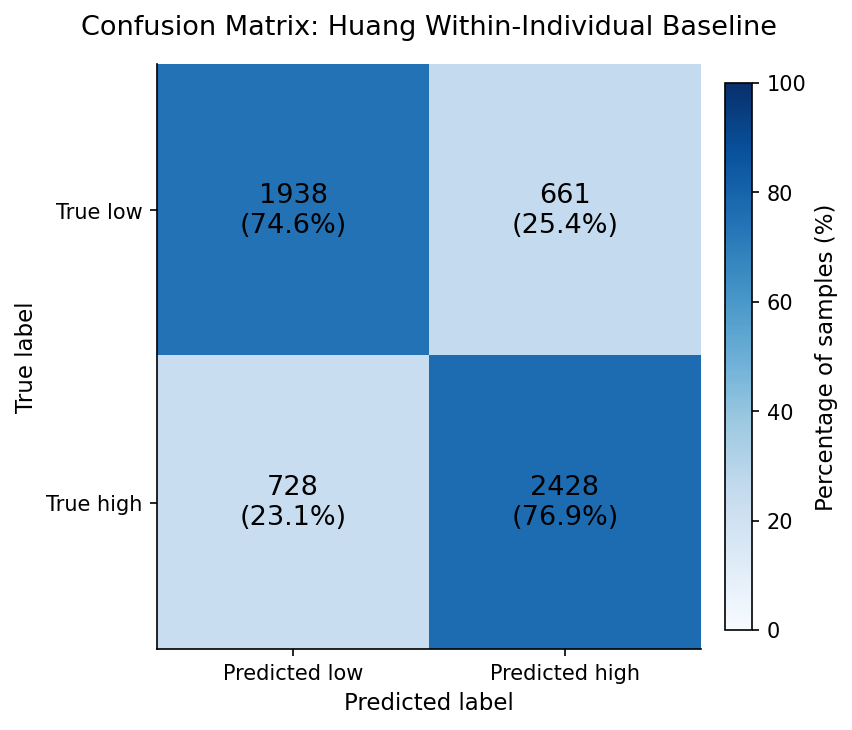

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_within_individual_confusion_matrix.png


In [ ]:
# 2. Confusion matrix

y_true = within_pred_df["pain_label"].values
y_pred = within_pred_df["prediction"].values

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5.8, 5.0))

im = ax.imshow(
    cm_percent,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted low", "Predicted high"])
ax.set_yticklabels(["True low", "True high"])

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix: Huang Within-Individual Baseline", pad=14)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="normal",
            color="black"
        )

ax.grid(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Percentage of samples (%)")

plt.tight_layout()
cm_fig_path = os.path.join(FIG_DIR, "huang_within_individual_confusion_matrix.png")
plt.savefig(cm_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", cm_fig_path)

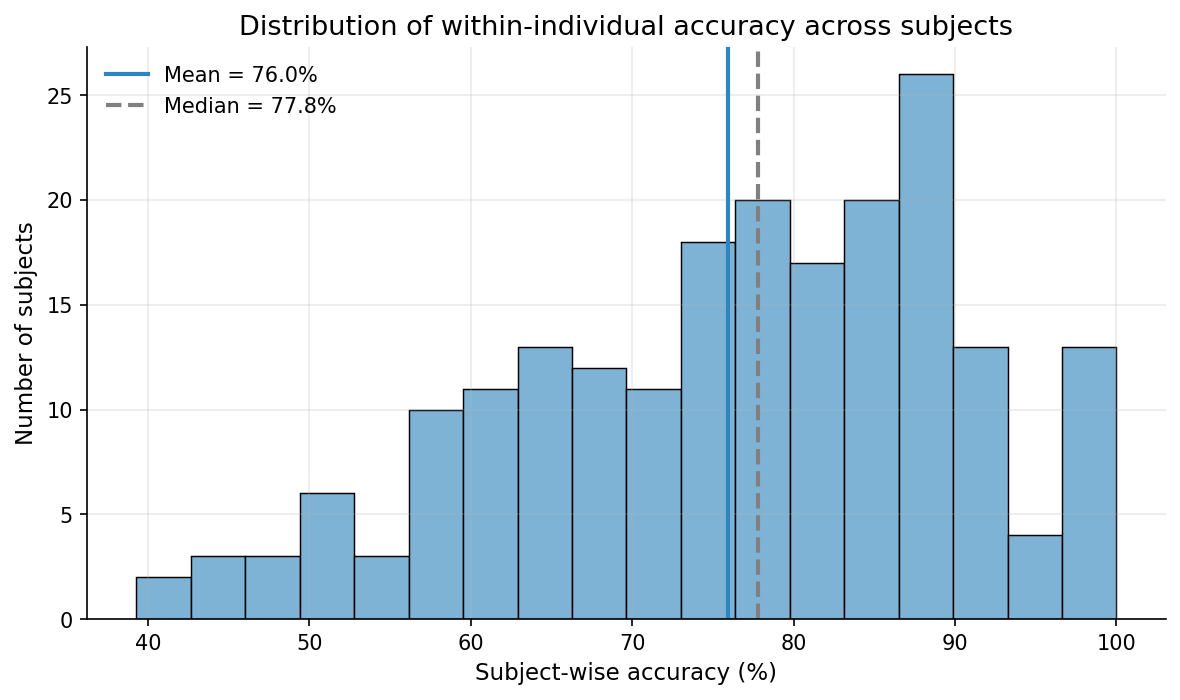

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_within_individual_subject_accuracy_distribution.png


In [ ]:
# 3. Subject-wise accuracy distribution

subject_acc = within_subject_df["accuracy"].values * 100

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.hist(
    subject_acc,
    bins=18,
    color="#7FB3D5",
    edgecolor="black",
    linewidth=0.7
)

mean_acc = np.mean(subject_acc)
median_acc = np.median(subject_acc)

ax.axvline(mean_acc, linestyle="-", linewidth=2, color="#2E86C1", label=f"Mean = {mean_acc:.1f}%")
ax.axvline(median_acc, linestyle="--", linewidth=2, color="gray", label=f"Median = {median_acc:.1f}%")

ax.set_xlabel("Subject-wise accuracy (%)")
ax.set_ylabel("Number of subjects")
ax.set_title("Distribution of within-individual accuracy across subjects")
ax.legend(frameon=False)

plt.tight_layout()
hist_fig_path = os.path.join(FIG_DIR, "huang_within_individual_subject_accuracy_distribution.png")
plt.savefig(hist_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", hist_fig_path)

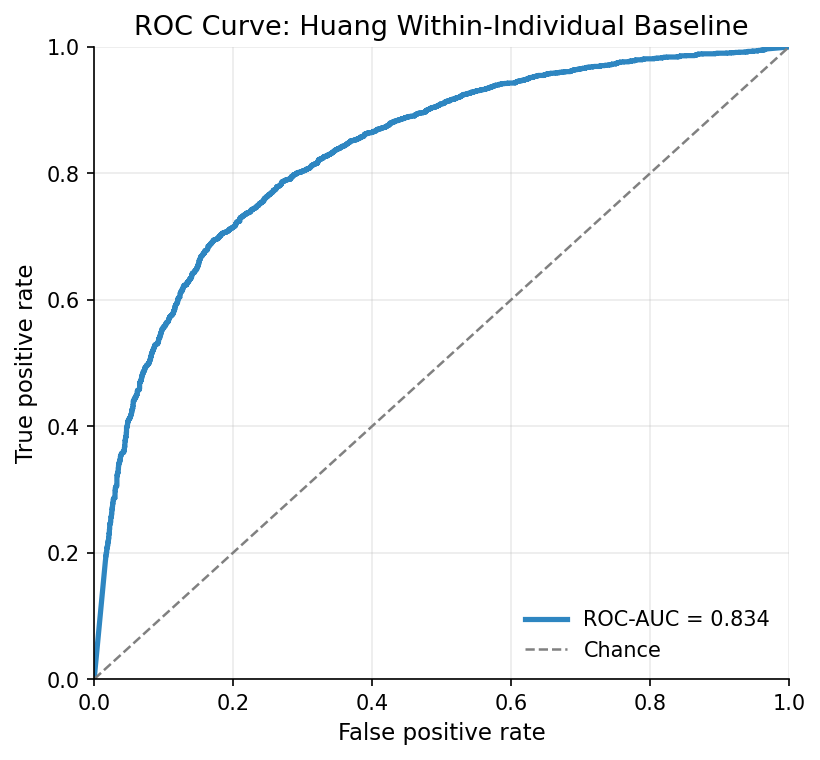

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_within_individual_roc_curve.png


In [ ]:
# 4. ROC curve

y_true = within_pred_df["pain_label"].values
y_prob = within_pred_df["prob_high"].values

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc_value = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.6, 5.2))

ax.plot(
    fpr,
    tpr,
    color="#2E86C1",
    linewidth=2.5,
    label=f"ROC-AUC = {roc_auc_value:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    color="gray",
    label="Chance"
)

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC Curve: Huang Within-Individual Baseline")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
roc_fig_path = os.path.join(FIG_DIR, "huang_within_individual_roc_curve.png")
plt.savefig(roc_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", roc_fig_path)

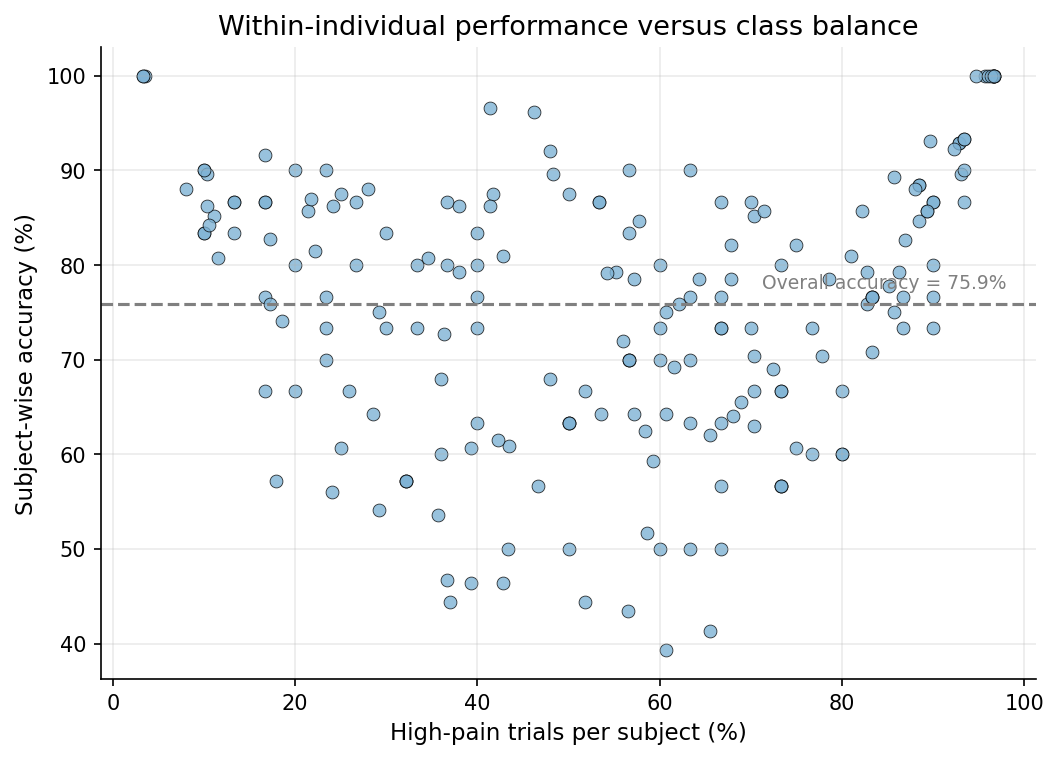

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_within_subject_accuracy_vs_class_balance.png


In [ ]:
# 5. Subject-wise accuracy vs class balance

plot_df = within_subject_df.copy()
plot_df["accuracy_percent"] = plot_df["accuracy"] * 100
plot_df["high_pain_ratio"] = plot_df["high_count"] / plot_df["n_trials"] * 100

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.scatter(
    plot_df["high_pain_ratio"],
    plot_df["accuracy_percent"],
    color="#7FB3D5",
    s=38,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4
)

ax.axhline(within_summary["accuracy"] * 100, linestyle="--", linewidth=1.5, color="gray")

ax.text(
    98,
    within_summary["accuracy"] * 100 + 1.2,
    f"Overall accuracy = {within_summary['accuracy']*100:.1f}%",
    ha="right",
    va="bottom",
    fontsize=9,
    color="gray"
)

ax.set_xlabel("High-pain trials per subject (%)")
ax.set_ylabel("Subject-wise accuracy (%)")
ax.set_title("Within-individual performance versus class balance")

plt.tight_layout()
scatter_fig_path = os.path.join(FIG_DIR, "huang_within_subject_accuracy_vs_class_balance.png")
plt.savefig(scatter_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", scatter_fig_path)

In [ ]:
print("within_subject_df exists:", "within_subject_df" in globals())
print("X_signal exists:", "X_signal" in globals())
print("times exists:", "times" in globals())

within_subject_df exists: True
X_signal exists: True
times exists: True


In [ ]:
# CELL 7A — Huang-faithful CROSS-INDIVIDUAL classification
# No feature scaling / no subject-wise normalization

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.naive_bayes import GaussianNB

logo = LeaveOneGroupOut()

cross_fold_rows = []
cross_pred_rows = []
cross_beta_rows = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X_signal, y_label, groups), start=1):

    test_subject = np.unique(groups[test_idx])[0]

    X_train = X_signal[train_idx]
    X_test = X_signal[test_idx]

    y_train = y_label[train_idx]
    y_test = y_label[test_idx]

    if len(np.unique(y_train)) < 2:
        continue

    # 1. CSP learned from training data only
    W_sel, A_sel = fit_huang_csp(X_train)

    # 2. Reconstruct LEP
    X_train_rec = apply_csp_reconstruct(X_train, W_sel, A_sel)
    X_test_rec = apply_csp_reconstruct(X_test, W_sel, A_sel)

    # 3. Cz post-stimulus response, 0–500 ms
    train_cz_post = X_train_rec[:, cz_idx, :][:, post_mask]
    test_cz_post = X_test_rec[:, cz_idx, :][:, post_mask]

    # 4. Eq(3) template from training average only
    D = make_np_templates(train_cz_post)

    # 5. β1–β5 features
    train_beta = extract_eq3_betas(train_cz_post, D)
    test_beta = extract_eq3_betas(test_cz_post, D)

    # 6. No scaling: closest to reported Huang method
    Xtr = train_beta.values
    Xte = test_beta.values

    # 7. Naive Bayes classifier
    clf = GaussianNB()
    clf.fit(Xtr, y_train)

    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    m = classification_metrics(y_test, y_pred, y_prob)

    cross_fold_rows.append({
        "fold": fold,
        "test_subject": test_subject,
        "n_test_trials": len(test_idx),
        "test_low": int((y_test == 0).sum()),
        "test_high": int((y_test == 1).sum()),
        **m
    })

    temp_pred = pd.DataFrame({
        "subject_id": groups[test_idx],
        "trial_num": trial_num[test_idx],
        "painrating": y_rating[test_idx],
        "pain_label": y_label[test_idx],
        "laser_power": laser_power[test_idx],
        "prediction": y_pred,
        "prob_high": y_prob,
        "fold": fold,
        "test_subject": test_subject
    })
    cross_pred_rows.append(temp_pred)

    temp_beta = test_beta.copy()
    temp_beta.insert(0, "subject_id", groups[test_idx])
    temp_beta.insert(1, "trial_num", trial_num[test_idx])
    temp_beta.insert(2, "painrating", y_rating[test_idx])
    temp_beta.insert(3, "pain_label", y_label[test_idx])
    temp_beta.insert(4, "fold", fold)
    cross_beta_rows.append(temp_beta)

    if fold % 25 == 0 or fold == len(np.unique(groups)):
        print(f"Done fold {fold}/{len(np.unique(groups))}")

cross_fold_df = pd.DataFrame(cross_fold_rows)
cross_pred_df = pd.concat(cross_pred_rows, ignore_index=True)
cross_beta_df = pd.concat(cross_beta_rows, ignore_index=True)

cross_summary = classification_metrics(
    cross_pred_df["pain_label"].values,
    cross_pred_df["prediction"].values,
    cross_pred_df["prob_high"].values
)

cross_summary_df = pd.DataFrame([{
    "experiment": "EXP8",
    "pipeline": "Huang Eq(3) faithful reconstructed baseline",
    "feature_set": "beta1-beta5",
    "classifier": "Gaussian Naive Bayes",
    "validation": "Leave-one-subject-out cross-individual",
    "normalization": "None",
    "subjects": len(np.unique(groups)),
    "trials": len(y_label),
    **cross_summary
}])

display(cross_summary_df)
display(cross_fold_df.head())

Done fold 25/223
Done fold 50/223
Done fold 75/223
Done fold 100/223
Done fold 125/223
Done fold 150/223
Done fold 175/223
Done fold 200/223
Done fold 223/223


,experiment,pipeline,feature_set,classifier,validation,normalization,subjects,trials,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,EXP8,Huang Eq(3) faithful reconstructed baseline,beta1-beta5,Gaussian Naive Bayes,Leave-one-subject-out cross-individual,None,223,6275,0.624701,0.638376,0.729896,0.534366,0.617011,0.664405


,fold,test_subject,n_test_trials,test_low,test_high,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,1,sub-001,28,11,17,0.535714,0.585561,0.750000,0.352941,0.480000,0.700535
1,2,sub-002,25,23,2,0.920000,0.500000,0.000000,0.000000,0.000000,0.847826
2,3,sub-003,25,18,7,0.880000,0.785714,1.000000,0.571429,0.727273,0.960317
3,4,sub-004,27,6,21,0.814815,0.702381,0.863636,0.904762,0.883721,0.706349
4,5,sub-005,27,13,14,0.481481,0.500000,0.000000,0.000000,0.000000,0.483516


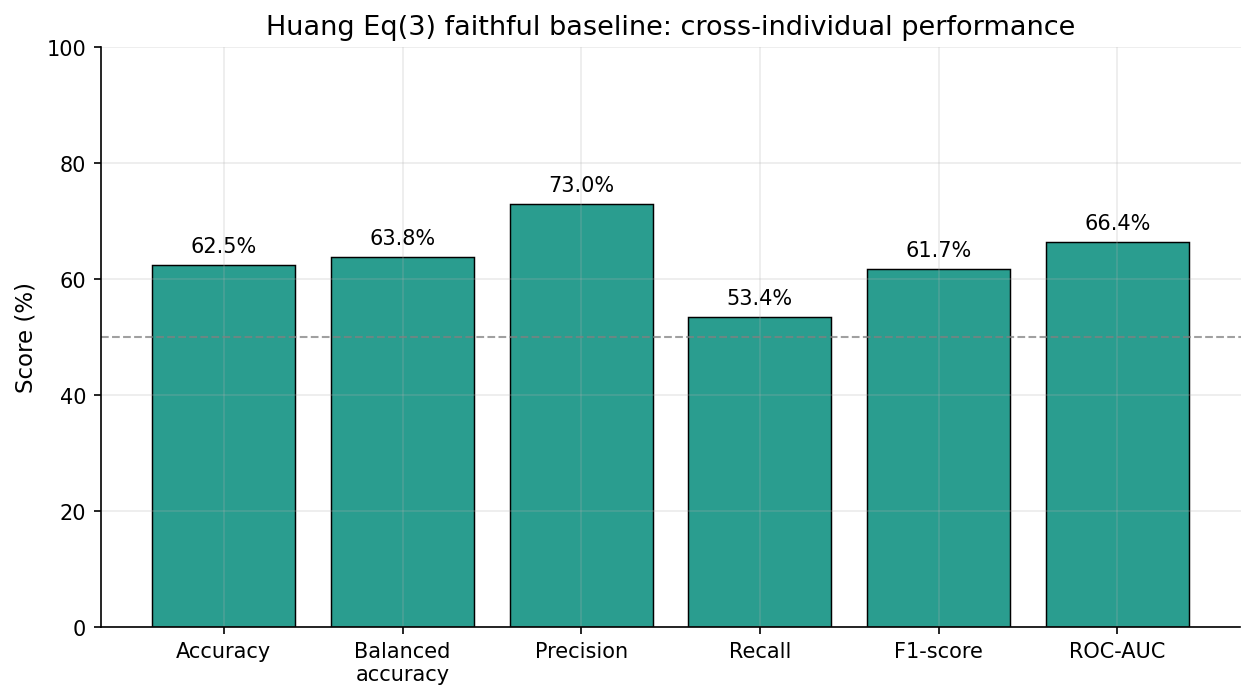

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_cross_individual_metric_summary_teal.png


In [ ]:
# 1. Summary metric bar plot — deep teal theme

import os
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

main_color = "#2A9D8F"
line_color = "#006D77"
gray_color = "gray"

metrics = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Balanced\naccuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
metric_values = [cross_summary[m] * 100 for m in metrics]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.bar(metric_labels, metric_values, color=main_color, edgecolor="black", linewidth=0.7)

ax.set_ylim(0, 100)
ax.set_ylabel("Score (%)")
ax.set_title("Huang Eq(3) faithful baseline: cross-individual performance")

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%",
            ha="center", va="bottom", fontsize=10)

ax.axhline(50, linestyle="--", linewidth=1.0, alpha=0.75, color=gray_color)

plt.tight_layout()
summary_fig_path = os.path.join(FIG_DIR, "huang_cross_individual_metric_summary_teal.png")
plt.savefig(summary_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", summary_fig_path)

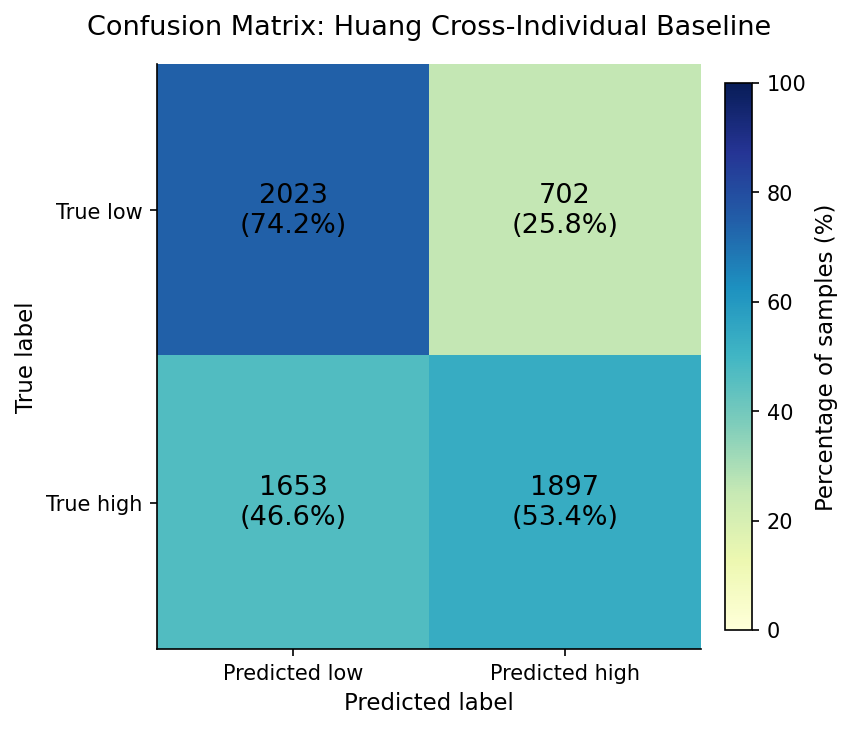

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_cross_individual_confusion_matrix_teal.png


In [ ]:
# 2. Confusion matrix — deep teal journal theme

from sklearn.metrics import confusion_matrix

y_true = cross_pred_df["pain_label"].values
y_pred = cross_pred_df["prediction"].values

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5.8, 5.0))

im = ax.imshow(cm_percent, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted low", "Predicted high"])
ax.set_yticklabels(["True low", "True high"])

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix: Huang Cross-Individual Baseline", pad=14)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
                ha="center", va="center", fontsize=13, color="black")

ax.grid(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Percentage of samples (%)")

plt.tight_layout()
cm_fig_path = os.path.join(FIG_DIR, "huang_cross_individual_confusion_matrix_teal.png")
plt.savefig(cm_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", cm_fig_path)

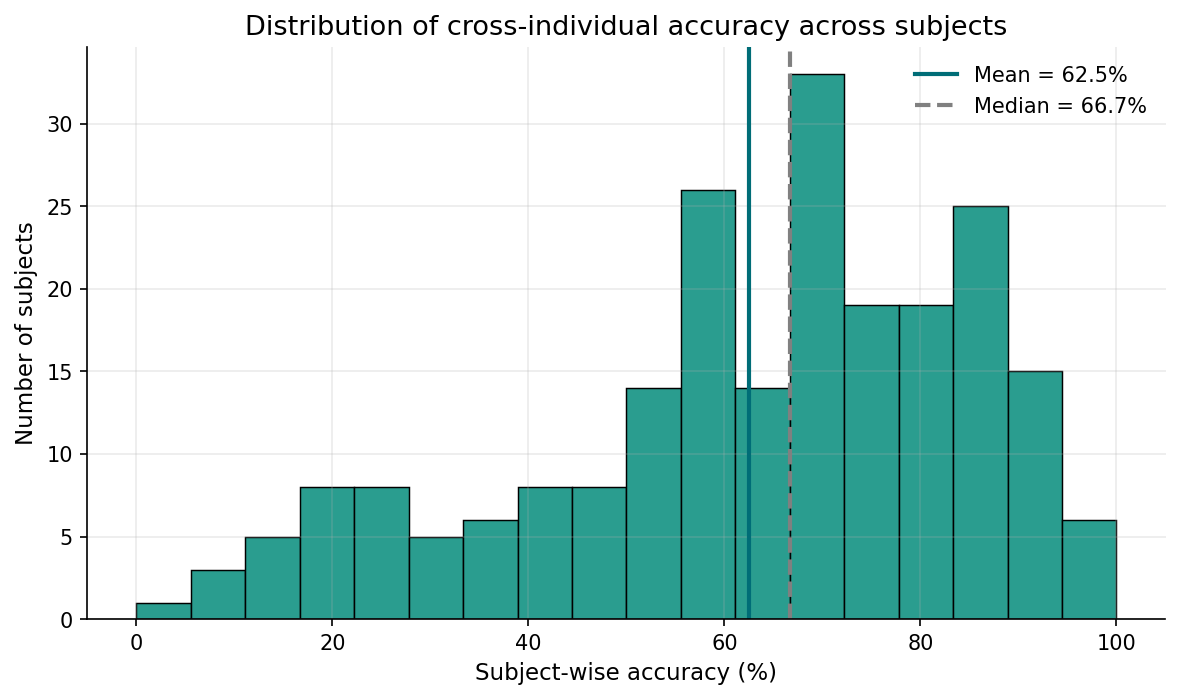

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_cross_individual_subject_accuracy_distribution_teal.png


In [ ]:
# 3. Subject-wise accuracy distribution — deep teal theme

subject_acc = cross_fold_df["accuracy"].values * 100

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.hist(subject_acc, bins=18, color=main_color, edgecolor="black", linewidth=0.7)

mean_acc = np.mean(subject_acc)
median_acc = np.median(subject_acc)

ax.axvline(mean_acc, linestyle="-", linewidth=2, color=line_color, label=f"Mean = {mean_acc:.1f}%")
ax.axvline(median_acc, linestyle="--", linewidth=2, color=gray_color, label=f"Median = {median_acc:.1f}%")

ax.set_xlabel("Subject-wise accuracy (%)")
ax.set_ylabel("Number of subjects")
ax.set_title("Distribution of cross-individual accuracy across subjects")
ax.legend(frameon=False)

plt.tight_layout()
hist_fig_path = os.path.join(FIG_DIR, "huang_cross_individual_subject_accuracy_distribution_teal.png")
plt.savefig(hist_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", hist_fig_path)

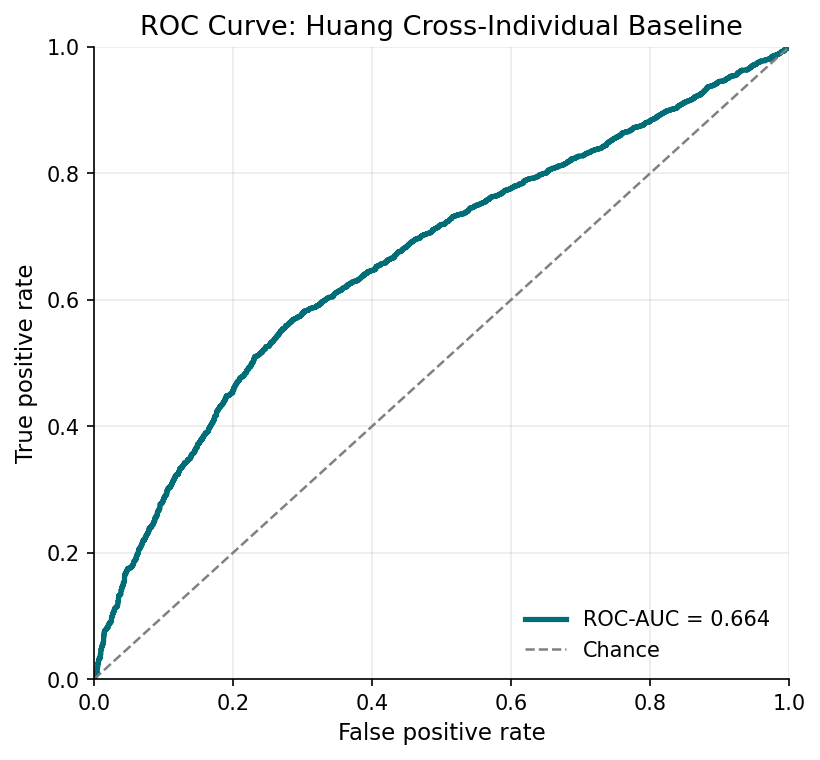

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_cross_individual_roc_curve_teal.png


In [ ]:
# 4. ROC curve — deep teal theme

from sklearn.metrics import roc_curve, auc

y_true = cross_pred_df["pain_label"].values
y_prob = cross_pred_df["prob_high"].values

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc_value = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.6, 5.2))

ax.plot(
    fpr,
    tpr,
    color=line_color,
    linewidth=2.5,
    label=f"ROC-AUC = {roc_auc_value:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    color=gray_color,
    label="Chance"
)

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC Curve: Huang Cross-Individual Baseline")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
roc_fig_path = os.path.join(FIG_DIR, "huang_cross_individual_roc_curve_teal.png")
plt.savefig(roc_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", roc_fig_path)

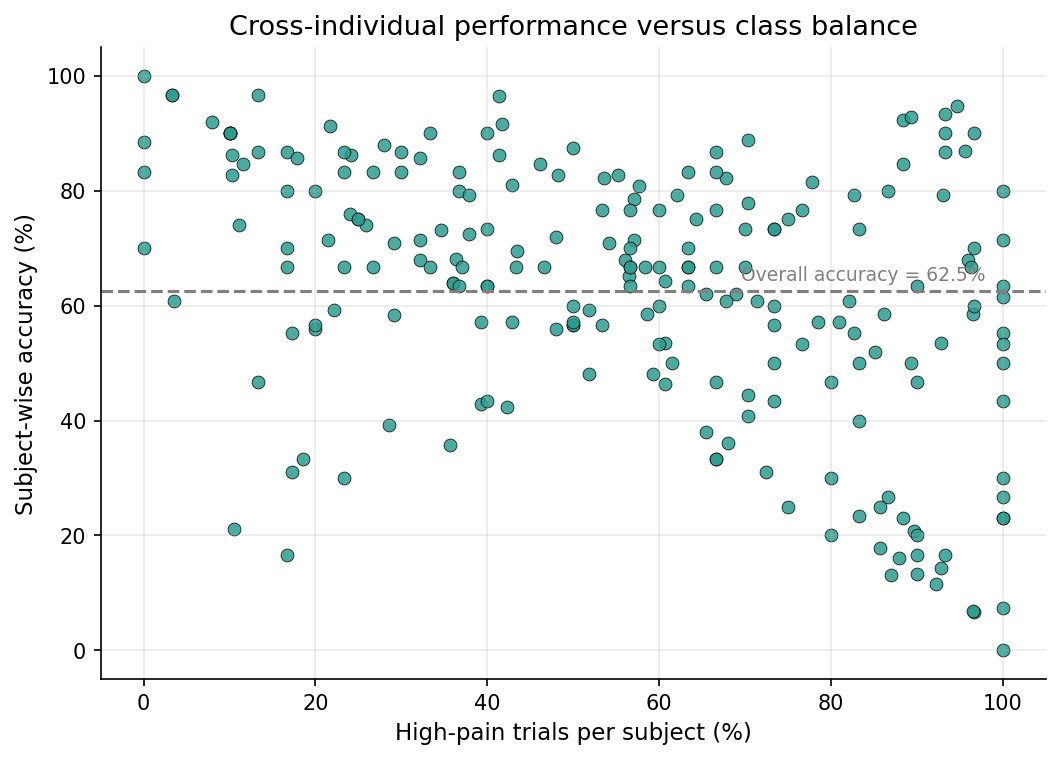

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_cross_subject_accuracy_vs_class_balance_teal.png


In [ ]:
# 5. Cross-individual performance versus class balance — deep teal theme

plot_df = cross_fold_df.copy()
plot_df["accuracy_percent"] = plot_df["accuracy"] * 100
plot_df["high_pain_ratio"] = plot_df["test_high"] / plot_df["n_test_trials"] * 100

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.scatter(
    plot_df["high_pain_ratio"],
    plot_df["accuracy_percent"],
    color=main_color,
    s=38,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4
)

ax.axhline(
    cross_summary["accuracy"] * 100,
    linestyle="--",
    linewidth=1.5,
    color=gray_color
)

ax.text(
    98,
    cross_summary["accuracy"] * 100 + 1.2,
    f"Overall accuracy = {cross_summary['accuracy']*100:.1f}%",
    ha="right",
    va="bottom",
    fontsize=9,
    color=gray_color
)

ax.set_xlabel("High-pain trials per subject (%)")
ax.set_ylabel("Subject-wise accuracy (%)")
ax.set_title("Cross-individual performance versus class balance")

plt.tight_layout()
scatter_fig_path = os.path.join(FIG_DIR, "huang_cross_subject_accuracy_vs_class_balance_teal.png")
plt.savefig(scatter_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", scatter_fig_path)

In [ ]:
# ===========================================
# Save Huang faithful CROSS-INDIVIDUAL results
# ===========================================

import os

SAVE_DIR = os.path.join(OUT_DIR, "saved_results")
os.makedirs(SAVE_DIR, exist_ok=True)

# Summary (1 row)
cross_summary_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_cross_individual_summary.csv"
)

# Subject-wise LOSO performance (223 rows)
cross_subject_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_cross_individual_subject_results.csv"
)

# Trial-wise predictions (6275 rows)
cross_prediction_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_cross_individual_predictions.csv"
)

# Beta features extracted from Huang Eq.(3)
cross_beta_path = os.path.join(
    SAVE_DIR,
    "EXP8_Huang_faithful_cross_individual_beta_features.csv"
)

# Save
cross_summary_df.to_csv(cross_summary_path, index=False)
cross_fold_df.to_csv(cross_subject_path, index=False)
cross_pred_df.to_csv(cross_prediction_path, index=False)
cross_beta_df.to_csv(cross_beta_path, index=False)

print("="*60)
print("Huang faithful CROSS-INDIVIDUAL results saved successfully.")
print("="*60)
print(cross_summary_path)
print(cross_subject_path)
print(cross_prediction_path)
print(cross_beta_path)

Huang faithful CROSS-INDIVIDUAL results saved successfully.
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_cross_individual_summary.csv
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_cross_individual_subject_results.csv
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_cross_individual_predictions.csv
/content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_cross_individual_beta_features.csv


In [ ]:
import os
for f in os.listdir(os.path.join(OUT_DIR, "saved_results")):
    print(f)

EXP8_Huang_faithful_cross_individual_summary.csv
EXP8_Huang_faithful_cross_individual_subject_results.csv
EXP8_Huang_faithful_cross_individual_predictions.csv
EXP8_Huang_faithful_cross_individual_beta_features.csv
EXP8_Huang_faithful_within_individual_summary.csv
EXP8_Huang_faithful_within_individual_subject_results.csv
EXP8_Huang_faithful_within_individual_predictions.csv
EXP8_Huang_faithful_within_individual_beta_features.csv


In [ ]:
huang_final_summary = pd.concat([cross_summary_df, within_summary_df], ignore_index=True)

final_path = os.path.join(OUT_DIR, "saved_results", "EXP8_Huang_faithful_FINAL_cross_vs_within_summary.csv")
huang_final_summary.to_csv(final_path, index=False)

display(huang_final_summary)
print("Saved:", final_path)

,experiment,pipeline,feature_set,classifier,validation,normalization,subjects,trials,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,subjects_used,trials_used
0,EXP8,Huang Eq(3) faithful reconstructed baseline,beta1-beta5,Gaussian Naive Bayes,Leave-one-subject-out cross-individual,None,223.0,6275.0,0.624701,0.638376,0.729896,0.534366,0.617011,0.664405,NaN,NaN
1,EXP8,Huang Eq(3) faithful reconstructed baseline,beta1-beta5,Gaussian Naive Bayes,Leave-one-trial-out within-individual,None,NaN,NaN,0.758645,0.757500,0.786015,0.769328,0.777582,0.834143,205.0,5755.0


Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/saved_results/EXP8_Huang_faithful_FINAL_cross_vs_within_summary.csv


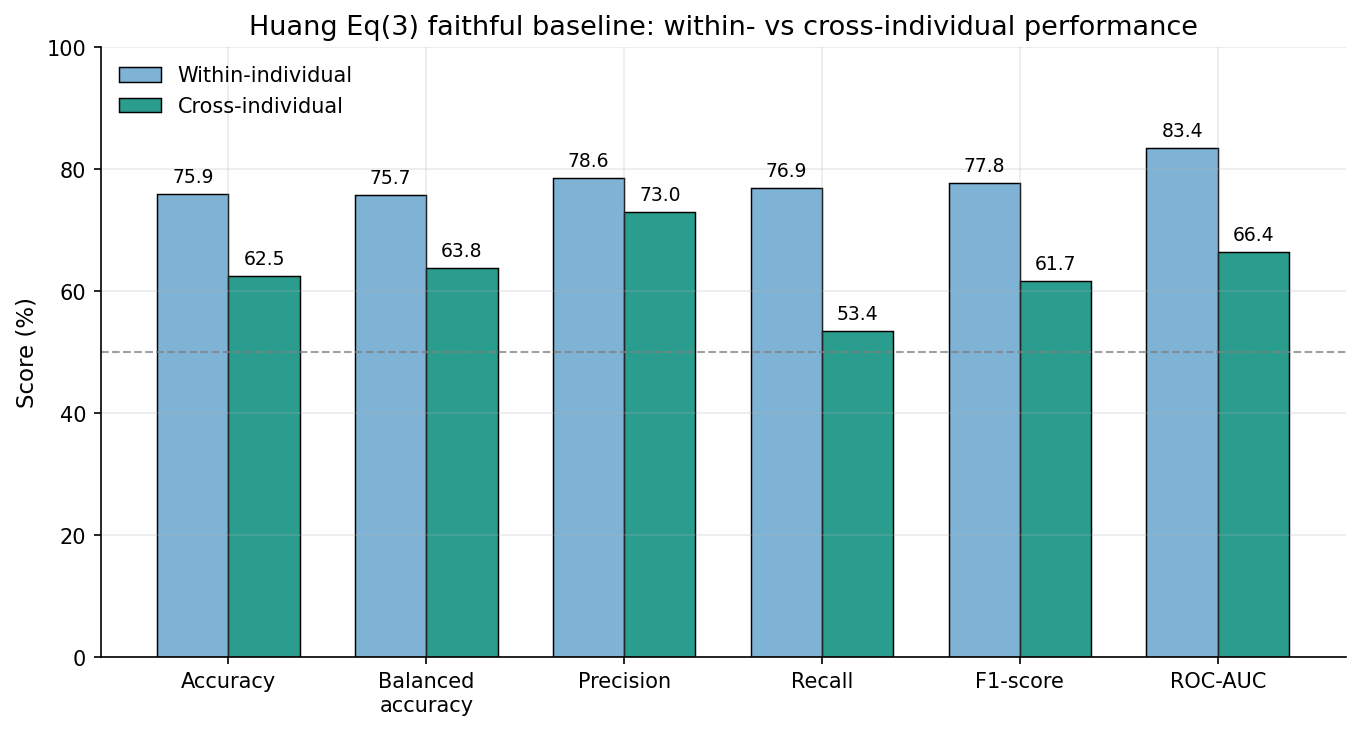

Saved: /content/drive/MyDrive/EXP8_HUANG_EQ3_CLASSIFICATION_CORRECTED/figures/huang_within_vs_cross_metric_comparison.png


In [ ]:
# Comparison figure — Within-individual vs Cross-individual Huang baseline

import os
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

metrics = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Balanced\naccuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

within_values = [within_summary[m] * 100 for m in metrics]
cross_values = [cross_summary[m] * 100 for m in metrics]

x = np.arange(len(metrics))
width = 0.36

within_color = "#7FB3D5"   # soft blue
cross_color = "#2A9D8F"    # deep teal

fig, ax = plt.subplots(figsize=(9.2, 5.0))

bars1 = ax.bar(
    x - width/2,
    within_values,
    width,
    label="Within-individual",
    color=within_color,
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x + width/2,
    cross_values,
    width,
    label="Cross-individual",
    color=cross_color,
    edgecolor="black",
    linewidth=0.7
)

ax.set_ylim(0, 100)
ax.set_ylabel("Score (%)")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_title("Huang Eq(3) faithful baseline: within- vs cross-individual performance")
ax.axhline(50, linestyle="--", linewidth=1.0, alpha=0.75, color="gray")
ax.legend(frameon=False)

for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 1.2,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

comparison_fig_path = os.path.join(FIG_DIR, "huang_within_vs_cross_metric_comparison.png")
plt.savefig(comparison_fig_path, bbox_inches="tight", dpi=600)
plt.show()

print("Saved:", comparison_fig_path)

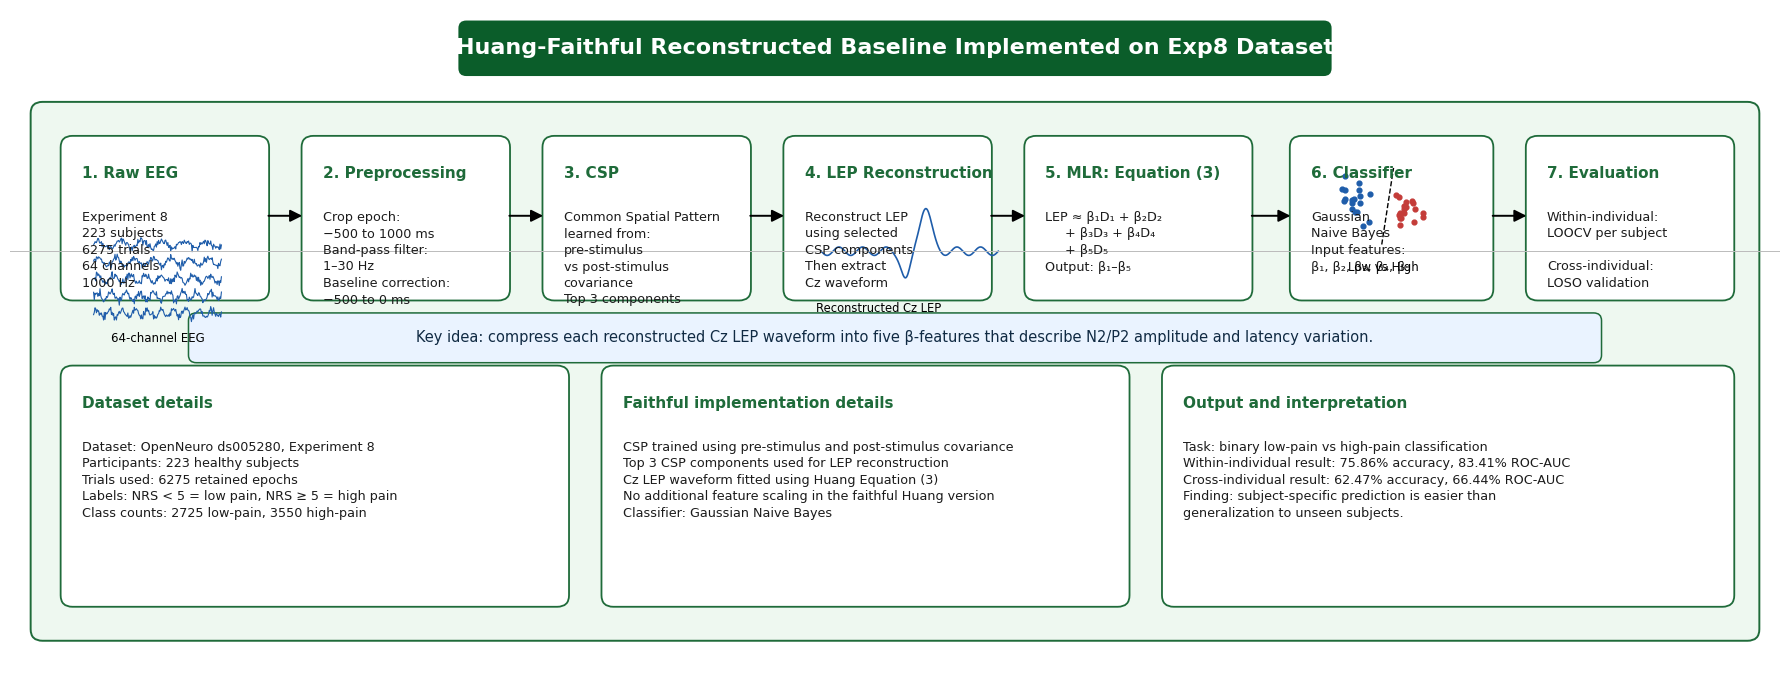

Saved:
/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES/huang_faithful_pipeline_exp8.png
/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES/huang_faithful_pipeline_exp8.pdf
/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES/huang_faithful_pipeline_exp8.svg


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import numpy as np
import os

FIG_DIR = "/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.8
})

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 18)
ax.set_ylim(0, 7)
ax.axis("off")

green = "#0B5D2A"
light_green = "#EEF8F0"
border = "#1F6B3A"
dark = "#1B1B1B"
blue = "#1F5DAA"
red = "#C43C39"
gray = "#666666"

def rounded_box(x, y, w, h, title, body, fc="white", ec=border):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.035,rounding_size=0.12",
        linewidth=1.3,
        edgecolor=ec,
        facecolor=fc
    )
    ax.add_patch(box)
    ax.text(x + 0.18, y + h - 0.28, title, fontsize=11, fontweight="bold",
            color=ec, va="top")
    ax.text(x + 0.18, y + h - 0.75, body, fontsize=9.2,
            color=dark, va="top", linespacing=1.35)
    return box

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.4,
        color="black"
    ))

def mini_eeg(x, y):
    t = np.linspace(0, 1, 180)
    for i in range(5):
        sig = 0.04*np.sin(2*np.pi*(6+i)*t) + 0.02*np.random.default_rng(i).normal(size=len(t))
        ax.plot(x + t*1.3, y - i*0.18 + sig, color=blue, lw=0.8)
    ax.text(x+0.65, y-1.02, "64-channel EEG", ha="center", fontsize=8.5)

def mini_waveform(x, y):
    t = np.linspace(-0.5, 1.0, 250)
    sig = (
        -0.55*np.exp(-((t-0.22)/0.055)**2)
        + 0.85*np.exp(-((t-0.38)/0.07)**2)
        + 0.08*np.sin(2*np.pi*5*t)
    )
    ax.plot(x + (t+0.5)*1.2, y + sig*0.55, color=blue, lw=1.2)
    ax.axhline(y, xmin=0, xmax=1, color="#BBBBBB", lw=0.7)
    ax.text(x+0.58, y-0.63, "Reconstructed Cz LEP", ha="center", fontsize=8.3)

def mini_classifier(x, y):
    rng = np.random.default_rng(4)
    p1 = rng.normal([0.25, 0.55], [0.08, 0.12], size=(18,2))
    p2 = rng.normal([0.75, 0.45], [0.08, 0.12], size=(18,2))
    ax.scatter(x+p1[:,0], y+p1[:,1], s=12, color=blue)
    ax.scatter(x+p2[:,0], y+p2[:,1], s=12, color=red)
    ax.plot([x+0.5, x+0.62], [y+0.1, y+0.9], color="black", lw=1, ls="--")
    ax.text(x+0.52, y-0.18, "Low vs High", ha="center", fontsize=8.5)

# Title
title_box = FancyBboxPatch(
    (4.6, 6.35), 8.8, 0.5,
    boxstyle="round,pad=0.04,rounding_size=0.08",
    linewidth=0,
    facecolor=green
)
ax.add_patch(title_box)
ax.text(9, 6.6,
        "Huang-Faithful Reconstructed Baseline Implemented on Exp8 Dataset",
        ha="center", va="center", color="white",
        fontsize=16, fontweight="bold")

# Outer border
outer = FancyBboxPatch(
    (0.25, 0.45), 17.5, 5.55,
    boxstyle="round,pad=0.04,rounding_size=0.12",
    linewidth=1.4,
    edgecolor=border,
    facecolor=light_green
)
ax.add_patch(outer)

# Boxes
rounded_box(
    0.55, 4.0, 2.05, 1.65,
    "1. Raw EEG",
    "Experiment 8\n223 subjects\n6275 trials\n64 channels\n1000 Hz",
)
mini_eeg(0.85, 4.55)

rounded_box(
    3.0, 4.0, 2.05, 1.65,
    "2. Preprocessing",
    "Crop epoch:\n−500 to 1000 ms\nBand-pass filter:\n1–30 Hz\nBaseline correction:\n−500 to 0 ms",
)

rounded_box(
    5.45, 4.0, 2.05, 1.65,
    "3. CSP",
    "Common Spatial Pattern\nlearned from:\npre-stimulus\nvs post-stimulus\ncovariance\nTop 3 components",
)

rounded_box(
    7.9, 4.0, 2.05, 1.65,
    "4. LEP Reconstruction",
    "Reconstruct LEP\nusing selected\nCSP components\nThen extract\nCz waveform",
)
mini_waveform(8.25, 4.48)

rounded_box(
    10.35, 4.0, 2.25, 1.65,
    "5. MLR: Equation (3)",
    "LEP ≈ β₁D₁ + β₂D₂\n     + β₃D₃ + β₄D₄\n     + β₅D₅\nOutput: β₁–β₅",
)

rounded_box(
    13.05, 4.0, 2.0, 1.65,
    "6. Classifier",
    "Gaussian\nNaive Bayes\nInput features:\nβ₁, β₂, β₃, β₄, β₅",
)
mini_classifier(13.45, 4.45)

rounded_box(
    15.45, 4.0, 2.05, 1.65,
    "7. Evaluation",
    "Within-individual:\nLOOCV per subject\n\nCross-individual:\nLOSO validation",
)

# Arrows
for x1, x2 in [(2.6, 3.0), (5.05, 5.45), (7.5, 7.9), (9.95, 10.35),
               (12.6, 13.05), (15.05, 15.45)]:
    arrow(x1, 4.85, x2, 4.85)

# Bottom information panels
rounded_box(
    0.55, 0.8, 5.1, 2.45,
    "Dataset details",
    "Dataset: OpenNeuro ds005280, Experiment 8\n"
    "Participants: 223 healthy subjects\n"
    "Trials used: 6275 retained epochs\n"
    "Labels: NRS < 5 = low pain, NRS ≥ 5 = high pain\n"
    "Class counts: 2725 low-pain, 3550 high-pain",
    fc="white"
)

rounded_box(
    6.05, 0.8, 5.3, 2.45,
    "Faithful implementation details",
    "CSP trained using pre-stimulus and post-stimulus covariance\n"
    "Top 3 CSP components used for LEP reconstruction\n"
    "Cz LEP waveform fitted using Huang Equation (3)\n"
    "No additional feature scaling in the faithful Huang version\n"
    "Classifier: Gaussian Naive Bayes",
    fc="white"
)

rounded_box(
    11.75, 0.8, 5.75, 2.45,
    "Output and interpretation",
    "Task: binary low-pain vs high-pain classification\n"
    "Within-individual result: 75.86% accuracy, 83.41% ROC-AUC\n"
    "Cross-individual result: 62.47% accuracy, 66.44% ROC-AUC\n"
    "Finding: subject-specific prediction is easier than\n"
    "generalization to unseen subjects.",
    fc="white"
)

# Key idea ribbon
ribbon = FancyBboxPatch(
    (1.85, 3.35), 14.3, 0.45,
    boxstyle="round,pad=0.035,rounding_size=0.08",
    linewidth=1.1,
    edgecolor=border,
    facecolor="#EAF3FF"
)
ax.add_patch(ribbon)
ax.text(
    9, 3.575,
    "Key idea: compress each reconstructed Cz LEP waveform into five β-features that describe N2/P2 amplitude and latency variation.",
    ha="center", va="center", fontsize=10.5, color="#102A43"
)

plt.tight_layout()

png_path = os.path.join(FIG_DIR, "huang_faithful_pipeline_exp8.png")
pdf_path = os.path.join(FIG_DIR, "huang_faithful_pipeline_exp8.pdf")
svg_path = os.path.join(FIG_DIR, "huang_faithful_pipeline_exp8.svg")

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)
print(svg_path)

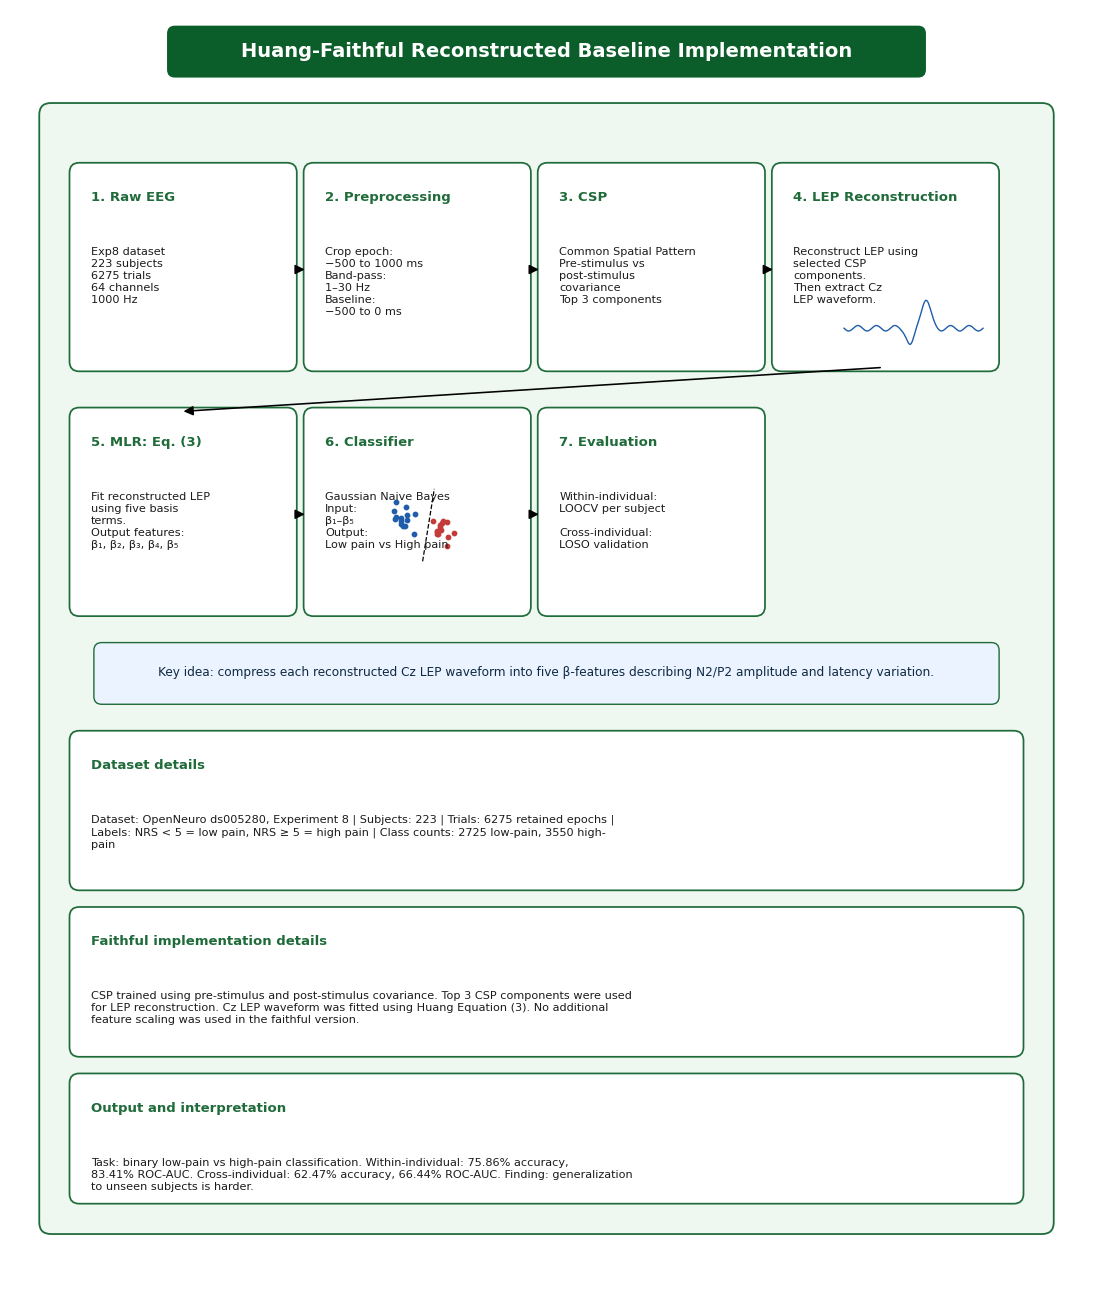

Saved:
/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES/huang_faithful_pipeline_exp8_tall.png
/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES/huang_faithful_pipeline_exp8_tall.pdf
/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES/huang_faithful_pipeline_exp8_tall.svg


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import os, textwrap

FIG_DIR = "/content/drive/MyDrive/EXP8_HUANG_BASELINE_FIGURES"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.linewidth": 0.8
})

fig, ax = plt.subplots(figsize=(11, 13))
ax.set_xlim(0, 11)
ax.set_ylim(0, 13)
ax.axis("off")

green = "#0B5D2A"
light_green = "#EEF8F0"
border = "#1F6B3A"
blue = "#1F5DAA"
red = "#C43C39"
dark = "#1B1B1B"

def wrap_text(text, width=28):
    lines = []
    for part in text.split("\n"):
        lines.extend(textwrap.wrap(part, width=width) if part.strip() else [""])
    return "\n".join(lines)

def rounded_box(x, y, w, h, title, body, fc="white", ec=border, wrap=25):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        linewidth=1.25,
        edgecolor=ec,
        facecolor=fc
    )
    ax.add_patch(box)
    ax.text(x + 0.18, y + h - 0.25, wrap_text(title, wrap),
            fontsize=9.5, fontweight="bold", color=ec, va="top")
    ax.text(x + 0.18, y + h - 0.82, wrap_text(body, wrap),
            fontsize=8.1, color=dark, va="top", linespacing=1.25)
    return box

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.15,
        color="black"
    ))

def mini_waveform(x, y, scale=1.0):
    t = np.linspace(-0.5, 1.0, 200)
    sig = (
        -0.45*np.exp(-((t-0.22)/0.055)**2)
        + 0.75*np.exp(-((t-0.38)/0.07)**2)
        + 0.07*np.sin(2*np.pi*5*t)
    )
    ax.plot(x + (t+0.5)*1.0*scale, y + sig*0.42*scale, color=blue, lw=1.0)

def mini_classifier(x, y):
    rng = np.random.default_rng(4)
    p1 = rng.normal([0.2, 0.55], [0.06, 0.08], size=(14,2))
    p2 = rng.normal([0.58, 0.45], [0.06, 0.08], size=(14,2))
    ax.scatter(x+p1[:,0], y+p1[:,1], s=10, color=blue)
    ax.scatter(x+p2[:,0], y+p2[:,1], s=10, color=red)
    ax.plot([x+0.38, x+0.50], [y+0.12, y+0.86], color="black", lw=0.9, ls="--")

# Title
title_box = FancyBboxPatch(
    (1.65, 12.35), 7.7, 0.45,
    boxstyle="round,pad=0.04,rounding_size=0.08",
    linewidth=0,
    facecolor=green
)
ax.add_patch(title_box)
ax.text(5.5, 12.575,
        "Huang-Faithful Reconstructed Baseline Implementation",
        ha="center", va="center", color="white",
        fontsize=14, fontweight="bold")

# Outer panel
outer = FancyBboxPatch(
    (0.35, 0.55), 10.3, 11.45,
    boxstyle="round,pad=0.05,rounding_size=0.12",
    linewidth=1.3,
    edgecolor=border,
    facecolor=light_green
)
ax.add_patch(outer)

# Top pipeline boxes: 2 rows instead of one long row
box_w = 2.25
box_h = 2.05

positions = [
    (0.65, 9.35), (3.05, 9.35), (5.45, 9.35), (7.85, 9.35),
    (0.65, 6.85), (3.05, 6.85), (5.45, 6.85)
]

rounded_box(positions[0][0], positions[0][1], box_w, box_h,
            "1. Raw EEG",
            "Exp8 dataset\n223 subjects\n6275 trials\n64 channels\n1000 Hz",
            wrap=22)

rounded_box(positions[1][0], positions[1][1], box_w, box_h,
            "2. Preprocessing",
            "Crop epoch:\n−500 to 1000 ms\nBand-pass:\n1–30 Hz\nBaseline:\n−500 to 0 ms",
            wrap=22)

rounded_box(positions[2][0], positions[2][1], box_w, box_h,
            "3. CSP",
            "Common Spatial Pattern\nPre-stimulus vs\npost-stimulus\ncovariance\nTop 3 components",
            wrap=22)

rounded_box(positions[3][0], positions[3][1], box_w, box_h,
            "4. LEP Reconstruction",
            "Reconstruct LEP using\nselected CSP components.\nThen extract Cz\nLEP waveform.",
            wrap=22)
mini_waveform(8.55, 9.75, scale=0.95)

rounded_box(positions[4][0], positions[4][1], box_w, box_h,
            "5. MLR: Eq. (3)",
            "Fit reconstructed LEP\nusing five basis terms.\nOutput features:\nβ₁, β₂, β₃, β₄, β₅",
            wrap=22)

rounded_box(positions[5][0], positions[5][1], box_w, box_h,
            "6. Classifier",
            "Gaussian Naive Bayes\nInput:\nβ₁–β₅\nOutput:\nLow pain vs High pain",
            wrap=22)
mini_classifier(3.85, 7.25)

rounded_box(positions[6][0], positions[6][1], box_w, box_h,
            "7. Evaluation",
            "Within-individual:\nLOOCV per subject\n\nCross-individual:\nLOSO validation",
            wrap=22)

# Arrows top row
arrow(2.90, 10.35, 3.05, 10.35)
arrow(5.30, 10.35, 5.45, 10.35)
arrow(7.70, 10.35, 7.85, 10.35)

# Down connector from LEP to MLR row
arrow(8.95, 9.35, 1.75, 8.90)
arrow(2.90, 7.85, 3.05, 7.85)
arrow(5.30, 7.85, 5.45, 7.85)

# Key idea ribbon
ribbon = FancyBboxPatch(
    (0.9, 5.95), 9.2, 0.55,
    boxstyle="round,pad=0.04,rounding_size=0.08",
    linewidth=1.0,
    edgecolor=border,
    facecolor="#EAF3FF"
)
ax.add_patch(ribbon)
ax.text(
    5.5, 6.23,
    "Key idea: compress each reconstructed Cz LEP waveform into five β-features describing N2/P2 amplitude and latency variation.",
    ha="center", va="center", fontsize=8.7, color="#102A43"
)

# Bottom details: vertical stack
rounded_box(
    0.65, 4.05, 9.7, 1.55,
    "Dataset details",
    "Dataset: OpenNeuro ds005280, Experiment 8 | Subjects: 223 | Trials: 6275 retained epochs | "
    "Labels: NRS < 5 = low pain, NRS ≥ 5 = high pain | Class counts: 2725 low-pain, 3550 high-pain",
    fc="white", wrap=92
)

rounded_box(
    0.65, 2.35, 9.7, 1.45,
    "Faithful implementation details",
    "CSP trained using pre-stimulus and post-stimulus covariance. Top 3 CSP components were used for LEP reconstruction. "
    "Cz LEP waveform was fitted using Huang Equation (3). No additional feature scaling was used in the faithful version.",
    fc="white", wrap=92
)

rounded_box(
    0.65, 0.85, 9.7, 1.25,
    "Output and interpretation",
    "Task: binary low-pain vs high-pain classification. Within-individual: 75.86% accuracy, 83.41% ROC-AUC. "
    "Cross-individual: 62.47% accuracy, 66.44% ROC-AUC. Finding: generalization to unseen subjects is harder.",
    fc="white", wrap=92
)

plt.tight_layout()

png_path = os.path.join(FIG_DIR, "huang_faithful_pipeline_exp8_tall.png")
pdf_path = os.path.join(FIG_DIR, "huang_faithful_pipeline_exp8_tall.pdf")
svg_path = os.path.join(FIG_DIR, "huang_faithful_pipeline_exp8_tall.svg")

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)
print(svg_path)